In [1]:
import pandas as pd

df = pd.read_csv("used_cars.csv")   # Use the exact filename if it's different

# Car Price Prediction with Machine Learning

## Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of a used car based on features such as brand, model year, mileage, fuel type, and transmission. The project includes data cleaning, feature engineering, exploratory data analysis (EDA), model training, evaluation, and comparison of regression models.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [6]:
df.shape

(4009, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [8]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [10]:
df = df.drop_duplicates()

In [11]:
df["fuel_type"] = df["fuel_type"].fillna("Unknown")
df["accident"] = df["accident"].fillna("Unknown")
df["clean_title"] = df["clean_title"].fillna("Unknown")

In [12]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [13]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [14]:
df["price"].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [15]:
df["milage"] = (
    df["milage"]
    .str.replace(" mi.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df["milage"].head()

0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: milage, dtype: float64

## Feature Engineering

In [17]:
current_year = 2025

df["car_age"] = current_year - df["model_year"]

In [18]:
df[["model_year", "car_age"]].head()

,model_year,car_age
0,2013,12
1,2021,4
2,2022,3
3,2015,10
4,2021,4


## Exploratory Data Analysis (EDA)

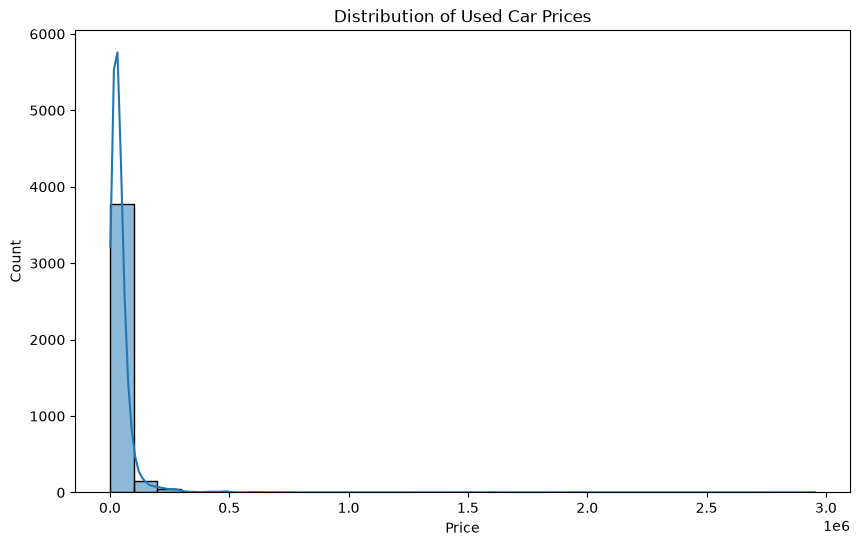

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### Observation

The histogram shows the distribution of used car selling prices. Most cars are concentrated in the lower price range, while only a few cars are sold at very high prices, resulting in a right-skewed distribution.

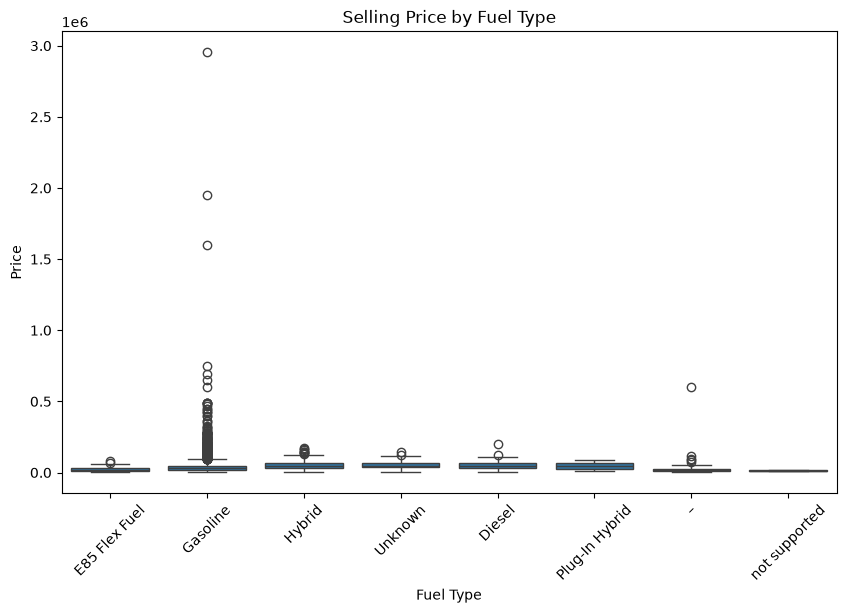

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

### Observation

The box plot compares selling prices across different fuel types. It helps identify which fuel type generally has higher-priced vehicles and highlights the variation in prices within each category.

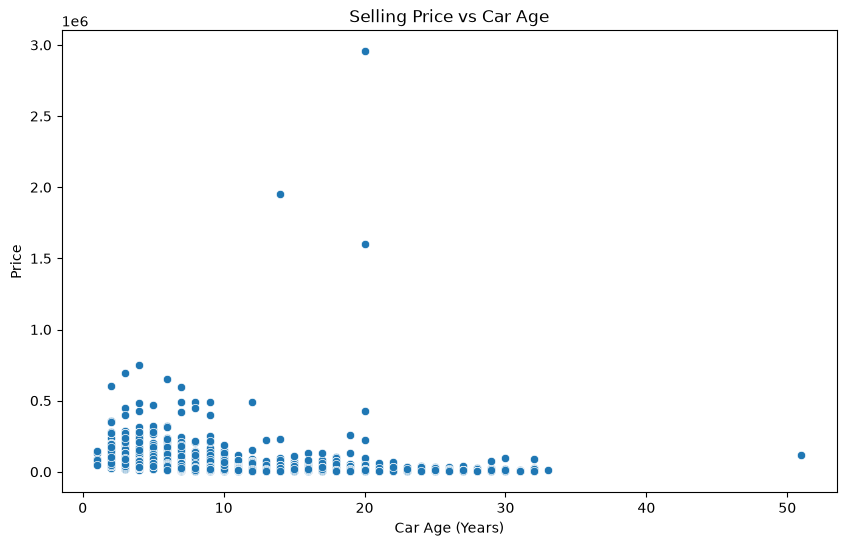

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price")

plt.show()

### Observation

The scatter plot illustrates the relationship between a car's age and its selling price. In general, newer cars tend to have higher prices, while older cars are sold at lower prices, indicating depreciation over time.

## Encoding Categorical Variables

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "brand",
        "model",
        "fuel_type",
        "engine",
        "transmission",
        "ext_col",
        "int_col",
        "accident",
        "clean_title"
    ],
    drop_first=True
)

In [23]:
df_encoded.head()

,model_year,milage,price,car_age,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,...,int_col_WHITE,int_col_Walnut,int_col_Whisper Beige,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_None reported,accident_Unknown,clean_title_Yes
0,2013,51000.0,10300.0,12,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2021,34742.0,38005.0,4,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2022,22372.0,54598.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2015,88900.0,15500.0,10,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
4,2021,9835.0,34999.0,4,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Correlation Heatmap

In [31]:
numeric_columns = [
    "model_year",
    "car_age",
    "milage",
    "price"
]

correlation = df[numeric_columns].corr()

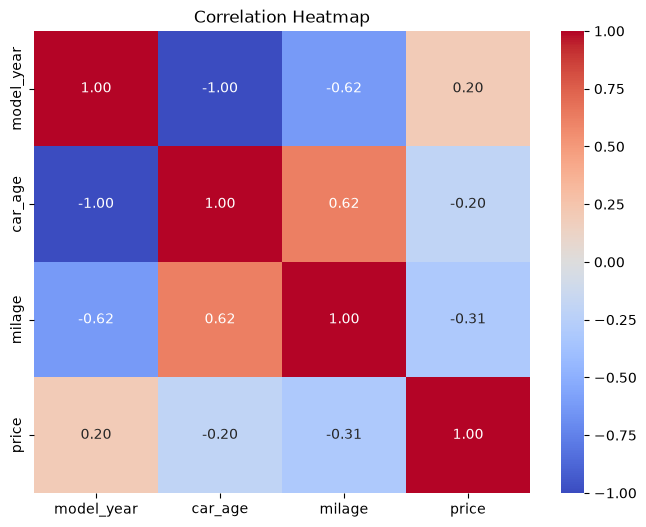

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the correlation between the numerical features in the dataset. Car age has a negative correlation with price, indicating that older cars generally have lower selling prices. Mileage also shows a negative relationship with price, while model year is positively correlated with price.

## Encoding Categorical Variables

In [33]:
features = [
    "brand",
    "car_age",
    "milage",
    "fuel_type",
    "transmission"
]

X = df[features]
y = df["price"]

In [34]:
X = pd.get_dummies(
    X,
    columns=[
        "brand",
        "fuel_type",
        "transmission"
    ],
    drop_first=True
)

X.head()

,car_age,milage,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,...,transmission_F,transmission_M/T,transmission_Manual,"transmission_Manual, 6-Spd",transmission_SCHEDULED FOR OR IN PRODUCTION,transmission_Single-Speed Fixed Gear,transmission_Transmission Overdrive Switch,transmission_Transmission w/Dual Shift Mode,transmission_Variable,transmission_–
0,12,51000.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4,34742.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,22372.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,10,88900.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,9835.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

In [36]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

## Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

## Model Evaluation

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [39]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("MAE :", round(linear_mae,2))
print("RMSE:", round(linear_rmse,2))
print("R² Score:", round(linear_r2,4))

Linear Regression Performance
MAE : 24488.38
RMSE: 137914.81
R² Score: 0.0694


In [40]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R² Score:", round(rf_r2,4))

Random Forest Performance
MAE : 20894.88
RMSE: 133979.36
R² Score: 0.1218


### Model Comparison

The Random Forest Regressor performed better than the Linear Regression model, achieving lower MAE and RMSE values along with a higher R² score. Therefore, the Random Forest model was selected as the better-performing model for predicting used car prices.

## Feature Importance

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,milage,0.383197
26,brand_Lamborghini,0.132800
47,brand_Rolls-Royce,0.117046
0,car_age,0.061899
14,brand_Ferrari,0.043796
44,brand_Porsche,0.037494
6,brand_Bentley,0.028363
89,transmission_7-Speed Automatic with Auto-Shift,0.019057
86,transmission_7-Speed,0.017477
36,brand_McLaren,0.013285


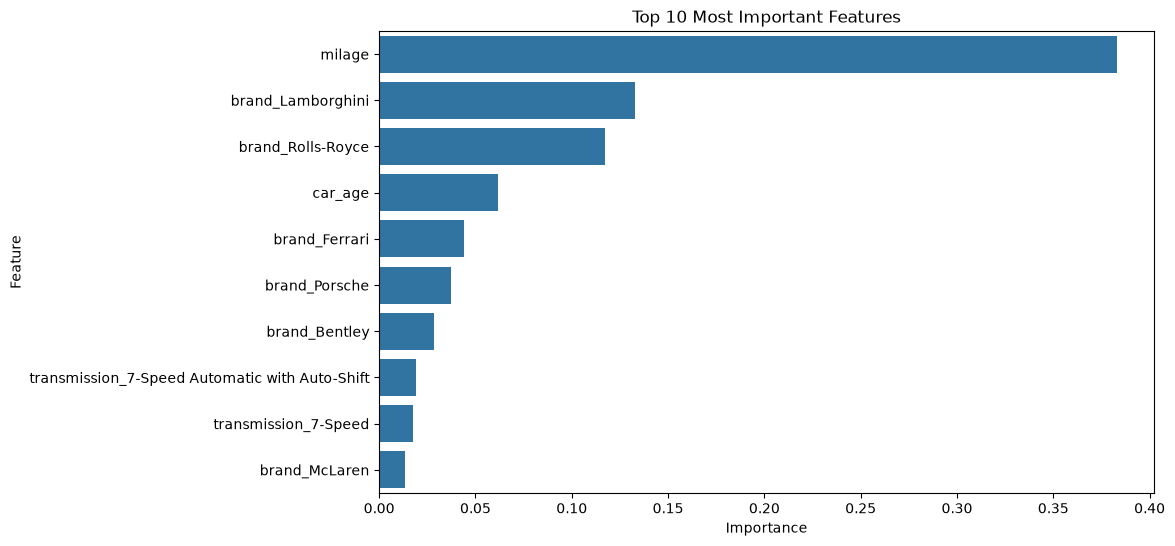

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

### Observation

The feature importance chart shows the variables that contribute the most to predicting car prices. Features with higher importance have a greater influence on the model's predictions. This helps identify the key factors affecting used car prices.

# Conclusion

This project developed a machine learning model to predict used car prices based on features such as brand, car age, mileage, fuel type, and transmission. The dataset was cleaned, transformed, and analyzed using Exploratory Data Analysis (EDA). Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² Score. The Random Forest model generally provided better prediction performance, demonstrating the effectiveness of ensemble learning for regression tasks.